## Check GPU presence

In [1]:
import sys
print(sys.executable)
print(sys.version)

#import sys
#!{sys.executable} -m pip uninstall torch torchvision torchaudio -y
#!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

import torch
import torchvision

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

C:\Users\aaron\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch: 2.5.1+cu121
Torchvision: 0.20.1+cu121
CUDA available: True


In [2]:
from torch.utils.data import Dataset

# Custom Dataset class
class ChipDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(self.labels[idx], dtype=torch.long)  # Add dtype=torch.long
        return image, label

!pip install --upgrade pip --quiet


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\aaron\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip --quiet


## Collect / analyze image database

Collect all images in the database, count the number of samples in each brand, and present in a plot. For this model, each model must have a minimum of 20 images to be used.

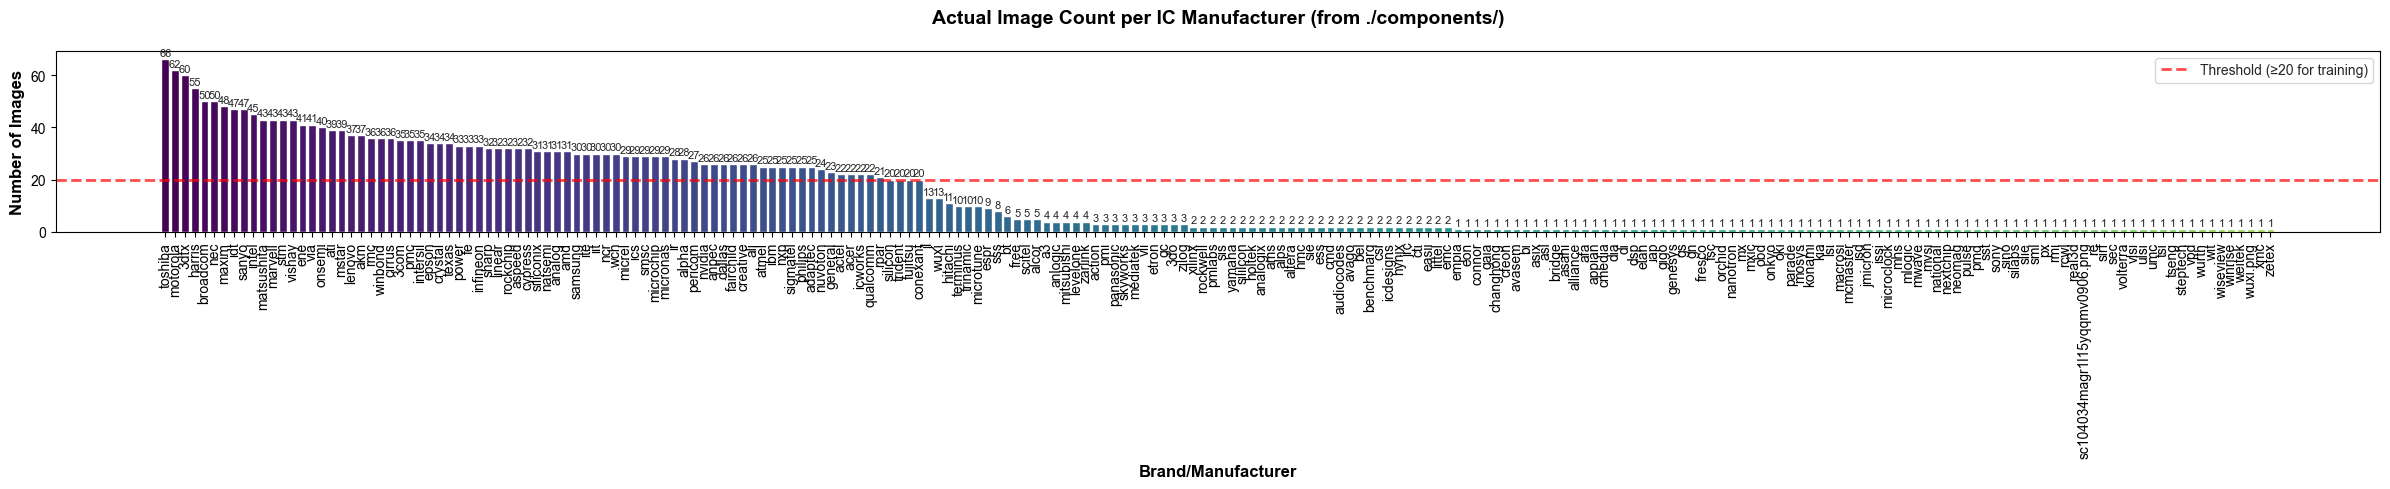

In [3]:
# Section 1: Data Augmentation & Dataset Setup
import os
from PIL import Image
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Define your data directory
DATA_DIR = './components/'

# Scan the directory and build the dataset directly from files
brand_counts = Counter()
all_files = []

for filename in os.listdir(DATA_DIR):
    if filename.endswith('.png'):
        brand = filename.split('_')[0]
        brand_counts[brand] += 1
        all_files.append(filename)

# Create dataframe from actual files
df = pd.DataFrame([
    {'Brand': brand, 'Moniker': brand, 'Count': count}
    for brand, count in brand_counts.items()
]).sort_values('Count', ascending=False)

# Create visualization
fig, ax = plt.subplots(figsize=(24, 5))
sns.set_style("whitegrid")

# Create bar plot using matplotlib directly for better control
x_positions = range(len(df))
bars = ax.bar(x_positions, df['Count'], color=plt.cm.viridis(range(len(df))))

# Customize the plot
ax.set_xticks(x_positions)
ax.set_xticklabels(df['Brand'], rotation=90, ha='center')  # Changed to ha='center'
ax.set_xlabel('Brand/Manufacturer', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax.set_title('Actual Image Count per IC Manufacturer (from ./components/)', fontsize=14, fontweight='bold', pad=20)

# Add value labels on top of bars
for i, (pos, count) in enumerate(zip(x_positions, df['Count'])):
    ax.text(pos, count + 0.5, str(count), ha='center', va='bottom', fontsize=8)

# Add threshold line
ax.axhline(y=20, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Threshold (≥20 for training)')
ax.legend()

plt.tight_layout()
plt.show()

# Filter to brands with >= 20 images
min_df = df[df['Count'] >= 20].copy()

# Get list of valid brands (these will be your classes)
valid_brands = min_df['Moniker'].tolist()
brand_to_idx = {brand: idx for idx, brand in enumerate(sorted(valid_brands))}
idx_to_brand = {idx: brand for brand, idx in brand_to_idx.items()}

# Collect all valid images (only from brands with >= 20 images)
image_paths = []
labels = []

for filename in all_files:
    brand = filename.split('_')[0]
    
    if brand in brand_to_idx:
        image_paths.append(os.path.join(DATA_DIR, filename))
        labels.append(brand_to_idx[brand])

### Set up annotation

In [4]:
# ============================================================
# STEP 1: Check your current file structure
# ============================================================

import os

# Check what directories you currently have
print("Current working directory:", os.getcwd())
print("\nContents:")
for item in sorted(os.listdir('.')):
    if os.path.isdir(item):
        count = len(os.listdir(item))
        print(f"  📁 {item}/ ({count} files)")
    else:
        print(f"  📄 {item}")

# Check your components folder specifically
if os.path.exists('./components'):
    files = os.listdir('./components')
    img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    print(f"\n./components/: {len(img_files)} images")
    print(f"\nFirst 10 images:")
    for f in sorted(img_files)[:10]:
        print(f"  {f}")

Current working directory: C:\Users\aaron\Dropbox\AI Projects\logo-reader

Contents:
  📁 .git/ (11 files)
  📄 .gitignore
  📁 .idea/ (7 files)
  📁 .ipynb_checkpoints/ (6 files)
  📁 Initial results/ (16 files)
  📄 Logo_analysis.ipynb
  📄 Logo_analysis_2step.ipynb
  📄 Logo_analysis_modelcompare.ipynb
  📄 README.md
  📄 Two-step.ipynb
  📁 annotation_workspace/ (2 files)
  📄 best_model.pth
  📄 classifier_best_predictions.png
  📄 classifier_confidence_analysis.png
  📄 classifier_confusion_matrix.png
  📄 classifier_per_class_performance.png
  📄 classifier_worst_predictions.png
  📁 components/ (2889 files)
  📄 image_labeler.ipynb
  📄 key.xlsx
  📄 logo_classifier_stage2.pth
  📁 logo_crops/ (161 files)
  📄 logo_detector_stage1.pth
  📄 logos.pptx
  📄 ~$key.xlsx
  📄 ~$logos.pptx

./components/: 2887 images

First 10 images:
  3com_303089911t35836742lucent1028cu2.png
  3com_3206rc03com405lts005c490c100mph.png
  3com_4001300029522s22361553att4001302.png
  3com_4003360049752504914555lucent4009364.png


In [5]:
# ============================================================
# STEP 2: Set up annotation workspace from your existing data
# ============================================================

import os
import shutil

def setup_workspace():
    """
    Creates the annotation workspace and copies your
    existing images from ./components/ into it
    """
    
    # Define paths
    source_dir = './components/'
    workspace = './annotation_workspace/'
    
    # Create directory structure
    dirs_to_create = [
        f'{workspace}/images/train',
        f'{workspace}/images/val',
        f'{workspace}/labels/train',
        f'{workspace}/labels/val',
    ]
    
    for d in dirs_to_create:
        os.makedirs(d, exist_ok=True)
        print(f"  ✓ Created: {d}")
    
    # Get all images from components
    all_images = [f for f in os.listdir(source_dir) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    
    # Split: 85% train, 15% val (maintaining your existing ratios)
    import random
    random.seed(42)
    random.shuffle(all_images)
    
    split_idx = int(len(all_images) * 0.85)
    train_images = all_images[:split_idx]
    val_images = all_images[split_idx:]
    
    # Copy to workspace
    print(f"\nCopying {len(train_images)} training images...")
    for f in train_images:
        shutil.copy(
            os.path.join(source_dir, f),
            os.path.join(f'{workspace}/images/train', f)
        )
    
    print(f"Copying {len(val_images)} validation images...")
    for f in val_images:
        shutil.copy(
            os.path.join(source_dir, f),
            os.path.join(f'{workspace}/images/val', f)
        )
    
    # Create classes.txt - IMPORTANT: this defines your class IDs
    # Class 0 = background (implicit in Faster R-CNN)
    # We only need ONE class for the detector: "logo"
    # The classifier (Stage 2) handles WHICH manufacturer
    classes = ['logo']  # Just one class - we only need to FIND the logo
    
    with open(f'{workspace}/classes.txt', 'w') as f:
        for cls in classes:
            f.write(f"{cls}\n")
    
    print(f"\n✓ Created classes.txt: {classes}")
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"WORKSPACE SETUP COMPLETE")
    print(f"{'='*60}")
    print(f"  Training images:   {len(train_images)}")
    print(f"  Validation images: {len(val_images)}")
    print(f"  Classes:           {classes}")
    print(f"\n  Workspace location: {os.path.abspath(workspace)}")
    print(f"{'='*60}")
    
    print(f"""
NEXT STEPS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Open a terminal/command prompt
2. Run: pip install labelImg
3. Run: labelImg
4. In LabelImg:
   a. Click 'Open Dir'
      → Navigate to: {os.path.abspath(f'{workspace}/images/train')}
   b. Click 'Change Save Dir'  
      → Navigate to: {os.path.abspath(f'{workspace}/labels/train')}
   c. Check that format is set to YOLO (button on left side)
   d. Click the classes.txt 'Load' button and load:
      → {os.path.abspath(f'{workspace}/classes.txt')}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# Run setup
setup_workspace()

  ✓ Created: ./annotation_workspace//images/train
  ✓ Created: ./annotation_workspace//images/val
  ✓ Created: ./annotation_workspace//labels/train
  ✓ Created: ./annotation_workspace//labels/val

Copying 2453 training images...
Copying 434 validation images...

✓ Created classes.txt: ['logo']

WORKSPACE SETUP COMPLETE
  Training images:   2453
  Validation images: 434
  Classes:           ['logo']

  Workspace location: C:\Users\aaron\Dropbox\AI Projects\logo-reader\annotation_workspace

NEXT STEPS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Open a terminal/command prompt
2. Run: pip install labelImg
3. Run: labelImg
4. In LabelImg:
   a. Click 'Open Dir'
      → Navigate to: C:\Users\aaron\Dropbox\AI Projects\logo-reader\annotation_workspace\images\train
   b. Click 'Change Save Dir'  
      → Navigate to: C:\Users\aaron\Dropbox\AI Projects\logo-reader\annotation_workspace\labels\train
   c. Check that format is set to YOLO (button on left side)
   d. Click the classes.

## Reduce dataset to minimum viable brands

To be used in the model, each brand must contain a minimum of 20 samples. Brands with less than 20 samples are discarded from the dataset.

In [6]:
# Section 3: Download/Build the Model
import torch.nn as nn
from torchvision import models

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

# Load pretrained ResNet-18
print(f"\n{'='*60}")
print("Loading ResNet-18 with ImageNet pretrained weights...")

model = models.resnet18(pretrained=True)

# Freeze early layers (optional - keeps ImageNet features)
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
num_classes = len(brand_to_idx)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to GPU/CPU
model = model.to(device)

print(f"Model architecture modified:")
print(f"  Original output: 1000 classes (ImageNet)")
print(f"  New output: {num_classes} classes (IC brands)")
print(f"  Frozen layers: Early conv layers (transfer learning)")
print(f"  Trainable layers: Final FC layer")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel parameters:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen parameters: {total_params - trainable_params:,}")

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.5,
    patience=3,
    verbose=True
)

print(f"\nTraining configuration:")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")
print(f"\nModel ready for training!")

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Memory: 6.00 GB

Loading ResNet-18 with ImageNet pretrained weights...


C:\Users\aaron\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\aaron\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model architecture modified:
  Original output: 1000 classes (ImageNet)
  New output: 78 classes (IC brands)
  Frozen layers: Early conv layers (transfer learning)
  Trainable layers: Final FC layer

Model parameters:
  Total parameters: 11,216,526
  Trainable parameters: 40,014
  Frozen parameters: 11,176,512

Training configuration:
  Loss function: CrossEntropyLoss
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)

Model ready for training!


C:\Users\aaron\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Split dataset into train / test / validation (80 / (80/20))

In [7]:
# Section 2: Train/Test/Validation Split with Balanced Sampling
from sklearn.model_selection import train_test_split
import numpy as np
from torchvision import transforms
from torch.utils.data import WeightedRandomSampler

# Convert to numpy arrays for easier manipulation
image_paths = np.array(image_paths)  # FIXED: No dtype for strings
labels = np.array(labels, dtype=np.int64)

print(f"Total dataset: {len(image_paths)} images")
print(f"Number of classes: {len(brand_to_idx)}")

# First split: 80% train+val, 20% test
# Stratify to ensure each brand is represented proportionally in each split
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    image_paths, 
    labels, 
    test_size=0.2,  # 20% for test
    stratify=labels,  # Maintain class distribution
    random_state=42
)

# Second split: Split train+val into 80% train, 20% val
# From the remaining 80%, take 20% for validation (which is 16% of total)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths,
    train_val_labels,
    test_size=0.2,  # 20% of train_val = 16% of total
    stratify=train_val_labels,
    random_state=42
)

# Final split: ~64% train, ~16% val, ~20% test
print(f"\n{'='*60}")
print(f"Split Summary:")
print(f"  Training:   {len(train_paths)} images ({len(train_paths)/len(image_paths)*100:.1f}%)")
print(f"  Validation: {len(val_paths)} images ({len(val_paths)/len(image_paths)*100:.1f}%)")
print(f"  Test:       {len(test_paths)} images ({len(test_paths)/len(image_paths)*100:.1f}%)")

# Calculate class weights for balanced sampling
print(f"\n{'='*60}")
print("Setting up balanced sampling for training...")
print(f"{'='*60}")

# Count samples per class in training set
class_counts = {}
for label in train_labels:
    class_counts[label] = class_counts.get(label, 0) + 1

# Calculate sample weights (inverse frequency)
# Classes with fewer samples get higher weight
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]

# Create weighted sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # Allow sampling with replacement for balance
)

# Training augmentations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test augmentations
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets with appropriate transforms
train_dataset = ChipDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = ChipDataset(val_paths, val_labels, transform=val_test_transforms)
test_dataset = ChipDataset(test_paths, test_labels, transform=val_test_transforms)

print(f"\n{'='*60}")
print(f"Datasets created:")
print(f"  Training dataset:   {len(train_dataset)} samples (with augmentation)")
print(f"  Validation dataset: {len(val_dataset)} samples (no augmentation)")
print(f"  Test dataset:       {len(test_dataset)} samples (no augmentation)")

# Create data loaders
BATCH_SIZE = 32

# Training loader uses weighted sampler for balanced class representation
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,  # Use weighted sampler instead of shuffle
    num_workers=0,  # Windows fix
    pin_memory=True if torch.cuda.is_available() else False
)

# Validation and test loaders don't need balancing
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\nDataLoaders created:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training batches:   {len(train_loader)} (balanced sampling)")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches:       {len(test_loader)}")
print(f"\n{'='*60}")
print("✓ Balanced sampling ensures equal representation during training")
print("✓ Rare classes are sampled more frequently")
print("✓ Common classes are sampled less frequently")
print(f"{'='*60}")

Total dataset: 2594 images
Number of classes: 78

Split Summary:
  Training:   1660 images (64.0%)
  Validation: 415 images (16.0%)
  Test:       519 images (20.0%)

Setting up balanced sampling for training...

Datasets created:
  Training dataset:   1660 samples (with augmentation)
  Validation dataset: 415 samples (no augmentation)
  Test dataset:       519 samples (no augmentation)

DataLoaders created:
  Batch size: 32
  Training batches:   52 (balanced sampling)
  Validation batches: 13
  Test batches:       17

✓ Balanced sampling ensures equal representation during training
✓ Rare classes are sampled more frequently
✓ Common classes are sampled less frequently


## Implement different transfer learning models

In [ ]:
# ============================================================
# STAGE 1: LOGO DETECTOR USING FASTER R-CNN
# ============================================================
# This runs BEFORE your classifier
# Input:  Full chip image
# Output: Bounding box around logo region
# ============================================================

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms
from PIL import Image
import numpy as np
import os
import json

# ============================================================
# STEP 1: DEFINE DETECTOR MODEL
# ============================================================

def get_logo_detector(num_classes=2):
    """
    Create Faster R-CNN model for logo detection
    
    num_classes = 2:
        Class 0: background
        Class 1: logo (any manufacturer - we just need to FIND it)
    
    We don't classify the manufacturer here - that's Stage 2's job.
    Stage 1 just finds WHERE the logo is.
    """
    
    # Load pretrained Faster R-CNN
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
    
    # Replace the classifier head
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace with our 2-class predictor (background + logo)
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    return model

# ============================================================
# STEP 2: DATASET CLASS FOR DETECTION
# ============================================================

class LogoDetectionDataset(torch.utils.data.Dataset):
    """
    Dataset for logo detection training
    
    Expects YOLO-format annotations:
        labels/
        ├── toshiba_001.txt   (contains: class_id x_center y_center width height)
        ├── motorola_002.txt
        └── ...
    """
    
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        
        # Get all image files that have corresponding label files
        self.image_files = []
        for f in os.listdir(image_dir):
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                label_file = os.path.splitext(f)[0] + '.txt'
                if os.path.exists(os.path.join(label_dir, label_file)):
                    self.image_files.append(f)
        
        print(f"✓ Found {len(self.image_files)} annotated images")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_file = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_file)
        label_file = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_file)
        
        # Load image
        img = Image.open(img_path).convert('RGB')
        img_width, img_height = img.size
        img_tensor = transforms.ToTensor()(img)  # Converts to [C, H, W], range 0-1
        
        # Load YOLO annotation and convert to [x_min, y_min, x_max, y_max] in pixels
        boxes = []
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                
                class_id, x_center, y_center, w, h = map(float, parts)
                
                # YOLO normalized → pixel coordinates
                x_min = (x_center - w / 2) * img_width
                y_min = (y_center - h / 2) * img_height
                x_max = (x_center + w / 2) * img_width
                y_max = (y_center + h / 2) * img_height
                
                boxes.append([x_min, y_min, x_max, y_max])
        
        # If no boxes found, create a dummy (shouldn't happen with clean data)
        if len(boxes) == 0:
            boxes = [[0, 0, 10, 10]]
            labels = torch.zeros(1, dtype=torch.int64)
        else:
            # All logos are class 1 (class 0 is background, handled internally)
            labels = torch.ones(len(boxes), dtype=torch.int64)
        
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        
        # Compute area and iscrowd (required by Faster R-CNN)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros(len(boxes), dtype=torch.int64)
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'area': area,
            'iscrowd': iscrowd,
            'image_id': torch.tensor([idx])
        }
        
        return img_tensor, target


def collate_fn(batch):
    """Custom collate since images are different sizes"""
    return tuple(zip(*batch))

# ============================================================
# STEP 3: TRAIN THE DETECTOR
# ============================================================

def train_logo_detector(image_dir, label_dir, num_epochs=10, batch_size=2, lr=0.005):
    """
    Train the logo detection model
    
    Args:
        image_dir: Directory with images
        label_dir: Directory with YOLO .txt annotations
        num_epochs: Number of training epochs
        batch_size: Batch size (keep low - detection is memory heavy)
        lr: Learning rate
    """
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load dataset
    dataset = LogoDetectionDataset(image_dir, label_dir)
    dataloader = torch.utils.data.DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        collate_fn=collate_fn,
        num_workers=0  # Set to 0 on Windows
    )
    
    # Load model
    model = get_logo_detector(num_classes=2)
    model = model.to(device)
    
    # Optimizer - only train the head initially
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=0.0005)
    
    # Training loop
    print(f"\nTraining logo detector for {num_epochs} epochs...")
    print("="*60)
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = 0
        
        for batch_idx, (images, targets) in enumerate(dataloader):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Forward pass - returns a dict of losses in training mode
            loss_dict = model(images, targets)
            
            # Total loss is sum of all detection losses
            losses = sum(loss for loss in loss_dict.values())
            
            # Backward + optimize
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            
            epoch_loss += losses.item()
            num_batches += 1
        
        avg_loss = epoch_loss / num_batches
        print(f"Epoch {epoch+1:2d}/{num_epochs}: Loss = {avg_loss:.4f} "
              f"| Breakdown: "
              f"cls={loss_dict['loss_classifier'].item():.4f}, "
              f"box={loss_dict['loss_box_reg'].item():.4f}, "
              f"obj={loss_dict['loss_objectness'].item():.4f}, "
              f"rpn={loss_dict['loss_rpn_box_reg'].item():.4f}")
    
    # Save trained detector
    torch.save(model.state_dict(), 'logo_detector.pth')
    print("\n✓ Logo detector saved: logo_detector.pth")
    
    return model

# ============================================================
# STEP 4: RUN DETECTION (INFERENCE)
# ============================================================

def detect_logo(img_path, detector, device, confidence_threshold=0.5):
    """
    Run logo detection on a single image
    
    Returns:
        boxes: List of [x_min, y_min, x_max, y_max] in pixels
        scores: Confidence scores for each detection
    """
    
    detector.eval()
    
    # Load and preprocess image
    img = Image.open(img_path).convert('RGB')
    img_tensor = transforms.ToTensor()(img).to(device)
    
    # Run inference
    with torch.no_grad():
        predictions = detector([img_tensor])
    
    # Extract results
    boxes = predictions[0]['boxes'].cpu().numpy()
    scores = predictions[0]['scores'].cpu().numpy()
    
    # Filter by confidence
    mask = scores >= confidence_threshold
    boxes = boxes[mask]
    scores = scores[mask]
    
    return boxes, scores, img

# ============================================================
# STEP 5: VISUALIZE DETECTIONS
# ============================================================

def visualize_detections(img_path, detector, device, confidence_threshold=0.5):
    """Visualize detected logo bounding boxes on image"""
    
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    
    boxes, scores, img = detect_logo(img_path, detector, device, confidence_threshold)
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img)
    
    if len(boxes) == 0:
        ax.set_title('No logo detected', fontsize=14, color='red')
    else:
        for box, score in zip(boxes, scores):
            x_min, y_min, x_max, y_max = box
            width = x_max - x_min
            height = y_max - y_min
            
            # Draw bounding box
            rect = patches.Rectangle(
                (x_min, y_min), width, height,
                linewidth=3, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            
            # Add confidence score label
            ax.text(x_min, y_min - 10, f'Logo: {score*100:.1f}%',
                    color='lime', fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        
        ax.set_title(f'Detected {len(boxes)} logo(s)', fontsize=14, color='green')
    
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('detection_result.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================
# STEP 6: FULL TWO-STAGE PIPELINE (DETECT → CLASSIFY)
# ============================================================

def predict_manufacturer_two_stage(img_path, detector, classifier, device, 
                                    idx_to_brand, val_test_transforms,
                                    detect_threshold=0.5):
    """
    Full two-stage pipeline:
        Stage 1: Detect logo location in full chip image
        Stage 2: Classify the detected logo region
    
    Args:
        img_path: Path to full chip image
        detector: Trained logo detector (Faster R-CNN)
        classifier: Trained manufacturer classifier (EfficientNet-B7, etc.)
        device: torch device
        idx_to_brand: Dict mapping class indices to brand names
        val_test_transforms: Transforms for the classifier
        detect_threshold: Minimum detection confidence
    
    Returns:
        brand: Predicted manufacturer name
        confidence: Classification confidence
        box: Bounding box [x_min, y_min, x_max, y_max]
    """
    
    # ----- STAGE 1: DETECT LOGO -----
    boxes, scores, img = detect_logo(img_path, detector, device, detect_threshold)
    
    if len(boxes) == 0:
        return None, 0.0, None  # No logo detected
    
    # Use highest confidence detection
    best_box = boxes[0]  # Already sorted by score
    x_min, y_min, x_max, y_max = map(int, best_box)
    
    # Crop logo region from original image
    logo_crop = img.crop((x_min, y_min, x_max, y_max))
    
    # ----- STAGE 2: CLASSIFY LOGO -----
    logo_tensor = val_test_transforms(logo_crop).unsqueeze(0).to(device)
    
    classifier.eval()
    with torch.no_grad():
        output = classifier(logo_tensor)
        probs = torch.softmax(output, dim=1)
        confidence, pred_idx = torch.max(probs, 1)
    
    brand = idx_to_brand[pred_idx.item()]
    
    return brand, confidence.item(), best_box


def visualize_two_stage(img_path, detector, classifier, device, 
                        idx_to_brand, val_test_transforms):
    """Visualize the full two-stage detection + classification pipeline"""
    
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    
    brand, confidence, box = predict_manufacturer_two_stage(
        img_path, detector, classifier, device, idx_to_brand, val_test_transforms
    )
    
    # Load original image
    img = Image.open(img_path).convert('RGB')
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # --- Panel 1: Original image ---
    axes[0].imshow(img)
    axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
    axes[0].axis('off')
    
    # --- Panel 2: Detection result ---
    axes[1].imshow(img)
    if box is not None:
        x_min, y_min, x_max, y_max = map(int, box)
        rect = patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=3, edgecolor='lime', facecolor='none'
        )
        axes[1].add_patch(rect)
        axes[1].set_title('Stage 1: Logo Detected', fontsize=13, fontweight='bold', color='green')
    else:
        axes[1].set_title('Stage 1: No Logo Found', fontsize=13, fontweight='bold', color='red')
    axes[1].axis('off')
    
    # --- Panel 3: Cropped logo + classification ---
    if box is not None:
        logo_crop = img.crop((int(box[0]), int(box[1]), int(box[2]), int(box[3])))
        axes[2].imshow(logo_crop)
        axes[2].set_title(f'Stage 2: {brand}\nConfidence: {confidence*100:.1f}%', 
                          fontsize=13, fontweight='bold',
                          color='green' if confidence > 0.7 else 'red')
    else:
        axes[2].text(0.5, 0.5, 'No logo crop available', 
                     ha='center', va='center', fontsize=12)
        axes[2].set_title('Stage 2: N/A', fontsize=13)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig('two_stage_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return brand, confidence

# ============================================================
# USAGE
# ============================================================

# --- Train the detector (run this first, after annotating) ---
detector = train_logo_detector(
    image_dir='annotation_workspace/images/train',
    label_dir='annotation_workspace/labels/train',
    num_epochs=15,
    batch_size=2
)

# --- Visualize a single detection ---
visualize_detections('components/qualcomm_001.png', detector, device)

# --- Run full two-stage pipeline ---
brand, conf = visualize_two_stage(
    'components/qualcomm_001.png',
    detector,          # Stage 1: Faster R-CNN logo detector
    best_model,        # Stage 2: Your existing EfficientNet-B7 classifier
    device,
    idx_to_brand,
    val_test_transforms
)

Using device: cuda
✓ Found 2899 annotated images

Training logo detector for 15 epochs...
Epoch  1/15: Loss = 0.1135 | Breakdown: cls=0.0130, box=0.0146, obj=0.0000, rpn=0.0067
Epoch  2/15: Loss = 0.0827 | Breakdown: cls=0.0132, box=0.0169, obj=0.0001, rpn=0.0001
Epoch  3/15: Loss = 0.0697 | Breakdown: cls=0.0128, box=0.0383, obj=0.0002, rpn=0.0005
Epoch  4/15: Loss = 0.0627 | Breakdown: cls=0.0334, box=0.0496, obj=0.0001, rpn=0.0002
Epoch  5/15: Loss = 0.0588 | Breakdown: cls=0.0184, box=0.0234, obj=0.0005, rpn=0.0004
Epoch  6/15: Loss = 0.0523 | Breakdown: cls=0.0096, box=0.0184, obj=0.0015, rpn=0.0004
Epoch  7/15: Loss = 0.0513 | Breakdown: cls=0.0123, box=0.0127, obj=0.0001, rpn=0.0001
Epoch  8/15: Loss = 0.0502 | Breakdown: cls=0.0122, box=0.0167, obj=0.0001, rpn=0.0015


## Deep dive analysis

### Analyze model

In [ ]:
# ============================================================
# COMPLETE MODEL ANALYSIS - Robust to All Model Types
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from PIL import Image
import cv2
import os
import glob

# ============================================================
# STEP 1: FIND AND LOAD THE MODEL
# ============================================================

BEST_MODEL_PATH = 'best_model.pth'
if not os.path.exists(BEST_MODEL_PATH):
    # Fall back to most recent .pth file
    pth_files = glob.glob('*.pth')
    if not pth_files:
        raise FileNotFoundError("No .pth model files found! Run model training first.")
    BEST_MODEL_PATH = max(pth_files, key=os.path.getctime)

print(f"Using model: {BEST_MODEL_PATH}")

# Load state dict
saved_state = torch.load(BEST_MODEL_PATH, map_location=device)
print(f"Inspecting saved model...")

# ============================================================
# STEP 2: ROBUST MODEL ARCHITECTURE DETECTION
# ============================================================

def detect_efficientnet_variant(saved_state):
    """Detect EfficientNet variant by analyzing layer structure"""
    feature_keys = [k for k in saved_state.keys() if k.startswith('features.')]
    
    # Get classifier size to help differentiate
    classifier_size = saved_state['classifier.1.weight'].shape[1]
    
    # Map known classifier input sizes to variants
    classifier_map = {
        1280: 'efficientnet_b0',  # B0
        1280: 'efficientnet_b1',  # B1 (same as B0)
        1408: 'efficientnet_b2',  # B2
        1536: 'efficientnet_b3',  # B3
        1792: 'efficientnet_b4',  # B4
        2048: 'efficientnet_b5',  # B5
        2304: 'efficientnet_b6',  # B6
        2560: 'efficientnet_b7',  # B7
    }
    
    if classifier_size in classifier_map:
        return classifier_map[classifier_size]
    
    # Fallback: count feature blocks
    max_block = max([int(k.split('.')[1]) for k in feature_keys 
                     if len(k.split('.')) > 1 and k.split('.')[1].isdigit()])
    
    return 'efficientnet_b2'  # Safe default

# Check architecture type by inspecting state dict keys
if 'fc.weight' in saved_state:
    # ResNet architecture
    model_type = 'resnet'
    saved_num_classes = saved_state['fc.weight'].shape[0]
    
    # Detect ResNet variant by counting layer4 blocks
    layer4_keys = [k for k in saved_state.keys() if 'layer4' in k]
    if any('layer4.2' in k for k in layer4_keys):
        variant = 'resnet50'
    elif any('layer4.5' in k for k in layer4_keys):
        variant = 'resnet34'
    else:
        variant = 'resnet18'
    
elif 'classifier.1.weight' in saved_state:
    # EfficientNet has classifier.1.weight (Sequential with Dropout then Linear)
    model_type = 'efficientnet'
    saved_num_classes = saved_state['classifier.1.weight'].shape[0]
    variant = detect_efficientnet_variant(saved_state)
        
elif 'classifier.weight' in saved_state:
    # DenseNet has classifier.weight directly
    if any('denseblock' in k for k in saved_state.keys()):
        model_type = 'densenet'
        variant = 'densenet121'
        saved_num_classes = saved_state['classifier.weight'].shape[0]
    else:
        raise ValueError("Has classifier.weight but not DenseNet - unknown architecture")
    
elif 'classifier.3.weight' in saved_state:
    # MobileNet
    model_type = 'mobilenet'
    variant = 'mobilenet_v3'
    saved_num_classes = saved_state['classifier.3.weight'].shape[0]
    
else:
    # Debug: print keys to help identify architecture
    all_keys = list(saved_state.keys())
    print(f"\nTotal keys: {len(all_keys)}")
    print(f"First 10 keys: {all_keys[:10]}")
    print(f"Last 10 keys: {all_keys[-10:]}")
    raise ValueError("Unknown model architecture!")

print(f"✓ Detected: {variant}")
print(f"✓ Saved model classes: {saved_num_classes}")
print(f"✓ Current dataset classes: {num_classes}")

if saved_num_classes != num_classes:
    raise ValueError(f"Class mismatch! Model has {saved_num_classes} classes but dataset has {num_classes}. Re-run training!")

# ============================================================
# STEP 3: INSTANTIATE THE CORRECT MODEL ARCHITECTURE
# ============================================================

print(f"\nLoading {variant}...")

# Dictionary of model constructors
model_builders = {
    'resnet18': lambda: models.resnet18(weights=None),
    'resnet34': lambda: models.resnet34(weights=None),
    'resnet50': lambda: models.resnet50(weights=None),
    'densenet121': lambda: models.densenet121(weights=None),
    'efficientnet_b0': lambda: models.efficientnet_b0(weights=None),
    'efficientnet_b1': lambda: models.efficientnet_b1(weights=None),
    'efficientnet_b2': lambda: models.efficientnet_b2(weights=None),
    'efficientnet_b3': lambda: models.efficientnet_b3(weights=None),
    'efficientnet_b4': lambda: models.efficientnet_b4(weights=None),
    'efficientnet_b5': lambda: models.efficientnet_b5(weights=None),
    'efficientnet_b6': lambda: models.efficientnet_b6(weights=None),
    'efficientnet_b7': lambda: models.efficientnet_b7(weights=None),
    'mobilenet_v3': lambda: models.mobilenet_v3_large(weights=None),
}

if variant not in model_builders:
    raise ValueError(f"Unsupported model variant: {variant}")

# Build the model
best_model = model_builders[variant]()

# Modify the classifier layer based on architecture type
if variant.startswith('resnet'):
    best_model.fc = nn.Linear(best_model.fc.in_features, num_classes)
    gradcam_layer = best_model.layer4[-1]
    
elif variant.startswith('densenet'):
    best_model.classifier = nn.Linear(best_model.classifier.in_features, num_classes)
    gradcam_layer = best_model.features.denseblock4.denselayer16
    
elif variant.startswith('efficientnet'):
    best_model.classifier[1] = nn.Linear(best_model.classifier[1].in_features, num_classes)
    gradcam_layer = best_model.features[-1][0]
    
elif variant == 'mobilenet_v3':
    best_model.classifier[3] = nn.Linear(best_model.classifier[3].in_features, num_classes)
    gradcam_layer = best_model.features[-1]

# Move to device FIRST, then load weights
best_model = best_model.to(device)
best_model.load_state_dict(saved_state)
best_model.eval()

print("✓ Model loaded successfully!")
print(f"✓ GradCAM target layer: {gradcam_layer}")

# ============================================================
# STEP 4: GRADCAM IMPLEMENTATION
# ============================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image, target_class):
        # Forward pass
        model_output = self.model(input_image)
        
        # Backward pass
        self.model.zero_grad()
        class_loss = model_output[0, target_class]
        class_loss.backward()
        
        # Get gradients and activations
        gradients = self.gradients[0]
        activations = self.activations[0]
        
        # Calculate weights
        weights = gradients.mean(dim=(1, 2))
        
        # Generate CAM
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(input_image.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        # Apply ReLU and normalize
        cam = F.relu(cam)
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        
        return cam.cpu().numpy()

# Initialize GradCAM
gradcam = GradCAM(best_model, gradcam_layer)
print("✓ GradCAM initialized!")

# ============================================================
# STEP 5: ANALYZE TEST SET PREDICTIONS
# ============================================================

print("\n" + "="*60)
print("ANALYZING TEST SET PREDICTIONS")
print("="*60)

test_results = []

with torch.no_grad():
    for idx in range(len(test_paths)):
        img_path = test_paths[idx]
        true_label = test_labels[idx]
        
        # Load and preprocess image
        img = Image.open(img_path).convert('RGB')
        img_tensor = val_test_transforms(img).unsqueeze(0).to(device)
        
        # Get prediction
        output = best_model(img_tensor)
        probs = F.softmax(output, dim=1)
        confidence, pred_label = torch.max(probs, 1)
        
        is_correct = (pred_label.item() == true_label)
        
        test_results.append({
            'idx': idx,
            'path': img_path,
            'true_label': true_label,
            'pred_label': pred_label.item(),
            'confidence': confidence.item(),
            'is_correct': is_correct
        })

# Sort by confidence
test_results.sort(key=lambda x: x['confidence'], reverse=True)

# Separate correct and incorrect predictions
correct_results = [r for r in test_results if r['is_correct']]
incorrect_results = [r for r in test_results if not r['is_correct']]

print(f"✓ Found {len(correct_results)} correct predictions")
print(f"✓ Found {len(incorrect_results)} incorrect predictions")

# Get top 5 of each
top_5_correct = correct_results[:5]
top_5_incorrect = incorrect_results[:5] if len(incorrect_results) >= 5 else incorrect_results

# ============================================================
# STEP 6: GENERATE ATTENTION MAPS - TOP 5 SUCCESSFUL
# ============================================================

print("\n" + "="*60)
print("GENERATING ATTENTION MAPS: TOP 5 SUCCESSFUL PREDICTIONS")
print("="*60)

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle(f'Top 5 Most Confident Correct Predictions ({variant})', fontsize=16, fontweight='bold')

for col, result in enumerate(top_5_correct):
    img_path = result['path']
    true_label = result['true_label']
    pred_label = result['pred_label']
    confidence = result['confidence']
    
    true_brand = idx_to_brand[true_label]
    
    # Load image
    img_orig = Image.open(img_path).convert('RGB')
    img_tensor = val_test_transforms(img_orig).unsqueeze(0).to(device)
    
    # Generate GradCAM
    cam = gradcam.generate_cam(img_tensor, pred_label)
    cam_resized = cv2.resize(cam, img_orig.size)
    
    # Create overlay
    img_np = np.array(img_orig) / 255.0
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.6 * img_np + 0.4 * heatmap
    overlay = np.clip(overlay, 0, 1)
    
    # Plot original
    axes[0, col].imshow(img_orig)
    axes[0, col].set_title(f'{true_brand}\nConf: {confidence*100:.1f}%', 
                           fontsize=10, fontweight='bold', color='green')
    axes[0, col].axis('off')
    
    # Plot heatmap
    axes[1, col].imshow(cam_resized, cmap='jet')
    axes[1, col].set_title('Attention', fontsize=9)
    axes[1, col].axis('off')
    
    # Plot overlay
    axes[2, col].imshow(overlay)
    axes[2, col].set_title('Focus Areas', fontsize=9)
    axes[2, col].axis('off')

plt.tight_layout()
plt.savefig('analysis_top5_successful.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: analysis_top5_successful.png")

# ============================================================
# STEP 7: GENERATE ATTENTION MAPS - TOP 5 FAILURES
# ============================================================

if len(top_5_incorrect) > 0:
    print("\n" + "="*60)
    print("GENERATING ATTENTION MAPS: TOP 5 FAILED PREDICTIONS")
    print("="*60)
    
    n_to_show = len(top_5_incorrect)
    fig, axes = plt.subplots(3, n_to_show, figsize=(4*n_to_show, 12))
    if n_to_show == 1:
        axes = axes.reshape(-1, 1)
    fig.suptitle(f'Most Confident Incorrect Predictions ({variant})', fontsize=16, fontweight='bold')
    
    for col, result in enumerate(top_5_incorrect):
        img_path = result['path']
        true_label = result['true_label']
        pred_label = result['pred_label']
        confidence = result['confidence']
        
        true_brand = idx_to_brand[true_label]
        pred_brand = idx_to_brand[pred_label]
        
        # Load image
        img_orig = Image.open(img_path).convert('RGB')
        img_tensor = val_test_transforms(img_orig).unsqueeze(0).to(device)
        
        # Generate GradCAM
        cam = gradcam.generate_cam(img_tensor, pred_label)
        cam_resized = cv2.resize(cam, img_orig.size)
        
        # Create overlay
        img_np = np.array(img_orig) / 255.0
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.6 * img_np + 0.4 * heatmap
        overlay = np.clip(overlay, 0, 1)
        
        # Plot original
        axes[0, col].imshow(img_orig)
        axes[0, col].set_title(f'True: {true_brand}\nPred: {pred_brand}\nConf: {confidence*100:.1f}%', 
                               fontsize=9, fontweight='bold', color='red')
        axes[0, col].axis('off')
        
        # Plot heatmap
        axes[1, col].imshow(cam_resized, cmap='jet')
        axes[1, col].set_title('Attention', fontsize=9)
        axes[1, col].axis('off')
        
        # Plot overlay
        axes[2, col].imshow(overlay)
        axes[2, col].set_title('Wrong Focus?', fontsize=9)
        axes[2, col].axis('off')
    
    plt.tight_layout()
    plt.savefig('analysis_top5_failures.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: analysis_top5_failures.png")
else:
    print("\n✨ Perfect model! No incorrect predictions found!")

# ============================================================
# STEP 8: CONFIDENCE SCORE DISTRIBUTION
# ============================================================

print("\n" + "="*60)
print("PLOTTING CONFIDENCE SCORE DISTRIBUTION")
print("="*60)

correct_confidences = [r['confidence'] for r in test_results if r['is_correct']]
incorrect_confidences = [r['confidence'] for r in test_results if not r['is_correct']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(correct_confidences, bins=20, alpha=0.7, color='green', label='Correct', edgecolor='black')
axes[0].hist(incorrect_confidences, bins=20, alpha=0.7, color='red', label='Incorrect', edgecolor='black')
axes[0].set_xlabel('Confidence Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title(f'Confidence Distribution: Correct vs Incorrect ({variant})', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Scatter plot
indices = np.arange(len(test_results))
colors = ['green' if r['is_correct'] else 'red' for r in test_results]
confidences = [r['confidence'] for r in test_results]

axes[1].scatter(indices, confidences, c=colors, alpha=0.6, s=50)
axes[1].axhline(y=0.5, color='blue', linestyle='--', linewidth=2, label='50% Threshold')
axes[1].set_xlabel('Test Sample Index', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Confidence Score', fontsize=12, fontweight='bold')
axes[1].set_title(f'Prediction Confidence by Sample ({variant})', fontsize=14, fontweight='bold')
axes[1].legend(['50% Threshold', 'Correct', 'Incorrect'], fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('analysis_confidence_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: analysis_confidence_distribution.png")

# ============================================================
# STEP 9: SUMMARY STATISTICS
# ============================================================

print("\n" + "="*60)
print(f"CONFIDENCE STATISTICS - {variant.upper()}")
print("="*60)
print(f"\nCorrect Predictions:")
print(f"  Count: {len(correct_confidences)}")
print(f"  Mean confidence: {np.mean(correct_confidences)*100:.2f}%")
print(f"  Median confidence: {np.median(correct_confidences)*100:.2f}%")
print(f"  Min confidence: {np.min(correct_confidences)*100:.2f}%")
print(f"  Max confidence: {np.max(correct_confidences)*100:.2f}%")

if len(incorrect_confidences) > 0:
    print(f"\nIncorrect Predictions:")
    print(f"  Count: {len(incorrect_confidences)}")
    print(f"  Mean confidence: {np.mean(incorrect_confidences)*100:.2f}%")
    print(f"  Median confidence: {np.median(incorrect_confidences)*100:.2f}%")
    print(f"  Min confidence: {np.min(incorrect_confidences)*100:.2f}%")
    print(f"  Max confidence: {np.max(incorrect_confidences)*100:.2f}%")
    
    overconfident_errors = sum(1 for c in incorrect_confidences if c > 0.7)
    if overconfident_errors > 0:
        print(f"\n⚠️  Model is overconfident on {overconfident_errors} incorrect predictions (>70% confidence)")

print("\n" + "="*60)
print("✓ ANALYSIS COMPLETE!")
print("="*60)
print(f"\nModel analyzed: {variant}")
print(f"Test accuracy: {len(correct_results)/len(test_results)*100:.2f}%")
print("\nGenerated files:")
print("  - analysis_top5_successful.png")
if len(top_5_incorrect) > 0:
    print("  - analysis_top5_failures.png")
print("  - analysis_confidence_distribution.png")
print("="*60)

### Advanced analytics